***1- Imports & Data loading***

Tree-based Models (AdaBoost, XGBoosst) don't need scaled features.

Trees split on thresholds - they don't care if weight is 0-150 and zone is 0-1.

So we load the UNSCALED parquets here (unlike baseline which used scaled).

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,                            
                            f1_score, roc_auc_score, confusion_matrix,
                            ConfusionMatrixDisplay, mean_absolute_error,                              
                            mean_squared_error, r2_score)
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent

# UNSCALED parquets — tree models handle raw values natively                                           
train_df = pd.read_parquet(ROOT / 'data' / 'train.parquet')                                          
val_df   = pd.read_parquet(ROOT / 'data' / 'val.parquet')                                              
test_df  = pd.read_parquet(ROOT / 'data' / 'test.parquet')

#NOT FEATURES, targets or leak info
target_cols = ['dim_flag', 'log_net_charge', 'Net Charge Billed Currency']

#define features as all cols not labeled as a target col
feature_cols = [c for c in train_df.columns if c not in target_cols]

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

#Task 1 targets: dim_flag is 1 (DIM=Y) or 0 (DIM=N)
y_train_cls = train_df['dim_flag']
y_val_cls = val_df['dim_flag']

#Task 2 targets: log_net_charge is the log-transformed shipping cost, bc of skewness
y_train_reg = train_df['log_net_charge']
y_val_reg = val_df['log_net_charge']

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Features: 34
Train: 41,820 | Val: 5,227 | Test: 5,228


***2- AdaBoost Classification***

In [12]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), #decision stumps
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_clf.fit(X_train, y_train_cls)

y_val_pred_ada = ada_clf.predict(X_val)
y_val_proba_ada = ada_clf.predict_proba(X_val)[:, 1]

print("=== AdaBoost Classification ===")                                                               
print(f"Accuracy:  {accuracy_score(y_val_cls, y_val_pred_ada):.4f}")
print(f"Precision: {precision_score(y_val_cls, y_val_pred_ada):.4f}")                                  
print(f"Recall:    {recall_score(y_val_cls, y_val_pred_ada):.4f}")                                   
print(f"F1:        {f1_score(y_val_cls, y_val_pred_ada):.4f}")                                         
print(f"ROC AUC:   {roc_auc_score(y_val_cls, y_val_proba_ada):.4f}")


=== AdaBoost Classification ===
Accuracy:  0.9960
Precision: 0.9939
Recall:    0.9962
F1:        0.9951
ROC AUC:   0.9992


***3- AdaBoost Regression***

In [13]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_reg.fit(X_train, y_train_reg)

#predict in log-space, then convert to dollars
y_val_pred_log_ada = ada_reg.predict(X_val)
y_val_pred_dollars_ada = np.expm1(y_val_pred_log_ada)
y_val_actual_dollars = val_df['Net Charge Billed Currency']

mae_ada = mean_absolute_error(y_val_actual_dollars, y_val_pred_dollars_ada)                            
rmse_ada = np.sqrt(mean_squared_error(y_val_actual_dollars, y_val_pred_dollars_ada))
r2_ada = r2_score(y_val_actual_dollars, y_val_pred_dollars_ada)

print('=== AdaBoost Regression ===')
print(f'MAE: ${mae_ada:.2f}')
print(f'RMSE: ${rmse_ada:.2f}')
print(f'R^2: {r2_ada:.2f}')

=== AdaBoost Regression ===
MAE: $10.66
RMSE: $16.70
R^2: 0.49


***4- XGBoost Classification***

In [14]:
#calculate class imbalance ration for scale_pos_weight
neg_count = (y_train_cls == 0).sum()
pos_count = (y_train_cls == 1).sum()
scale_ratio = neg_count / pos_count

xgb_clf = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6, #each tree can have up to 6 levels of splits
    subsample=0.8, #each tree sees 80% of rows (random subset)- reduces overfitting
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_ratio,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0 #suppress training logs
)

xgb_clf.fit(
    X_train, y_train_cls,
    eval_set=[(X_val, y_val_cls)], #monitor validation loss for early stopping
    verbose=False
)

y_val_pred_xgb = xgb_clf.predict(X_val)
y_val_proba_xgb = xgb_clf.predict_proba(X_val)[:, 1]

print(f"=== XGBoost Classification (stopped at {xgb_clf.best_iteration} trees) ===")                   
print(f"Accuracy:  {accuracy_score(y_val_cls, y_val_pred_xgb):.4f}")                                   
print(f"Precision: {precision_score(y_val_cls, y_val_pred_xgb):.4f}")                                  
print(f"Recall:    {recall_score(y_val_cls, y_val_pred_xgb):.4f}")                                     
print(f"F1:        {f1_score(y_val_cls, y_val_pred_xgb):.4f}")                                         
print(f"ROC AUC:   {roc_auc_score(y_val_cls, y_val_proba_xgb):.4f}")

=== XGBoost Classification (stopped at 63 trees) ===
Accuracy:  0.9990
Precision: 0.9986
Recall:    0.9991
F1:        0.9988
ROC AUC:   0.9999


***5- XGBoost Regression***

In [15]:
xgb_reg = xgb.XGBRegressor(                                                                          
    n_estimators=1000,
    max_depth=6,                                                                                       
    learning_rate=0.05,
    subsample=0.8,                                                                                     
    colsample_bytree=0.8,                                                                            
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',                                                                      
    eval_metric='rmse',
    early_stopping_rounds=20,                                                                          
    random_state=42,                                                                                 
    verbosity=0
)

xgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=False
)

y_val_pred_log_xgb = xgb_reg.predict(X_val)                                                            
y_val_pred_dollars_xgb = np.expm1(y_val_pred_log_xgb)

mae_xgb = mean_absolute_error(y_val_actual_dollars, y_val_pred_dollars_xgb)                            
rmse_xgb = np.sqrt(mean_squared_error(y_val_actual_dollars, y_val_pred_dollars_xgb))
r2_xgb = r2_score(y_val_actual_dollars, y_val_pred_dollars_xgb)                                        
                                                                                                        
print(f"=== XGBoost Regression (stopped at {xgb_reg.best_iteration} trees) ===")
print(f"MAE:  ${mae_xgb:.2f}")                                                                         
print(f"RMSE: ${rmse_xgb:.2f}")                                                                        
print(f"R²:   {r2_xgb:.4f}")

=== XGBoost Regression (stopped at 593 trees) ===
MAE:  $4.26
RMSE: $6.73
R²:   0.9174


***6- Confusion Matrix***

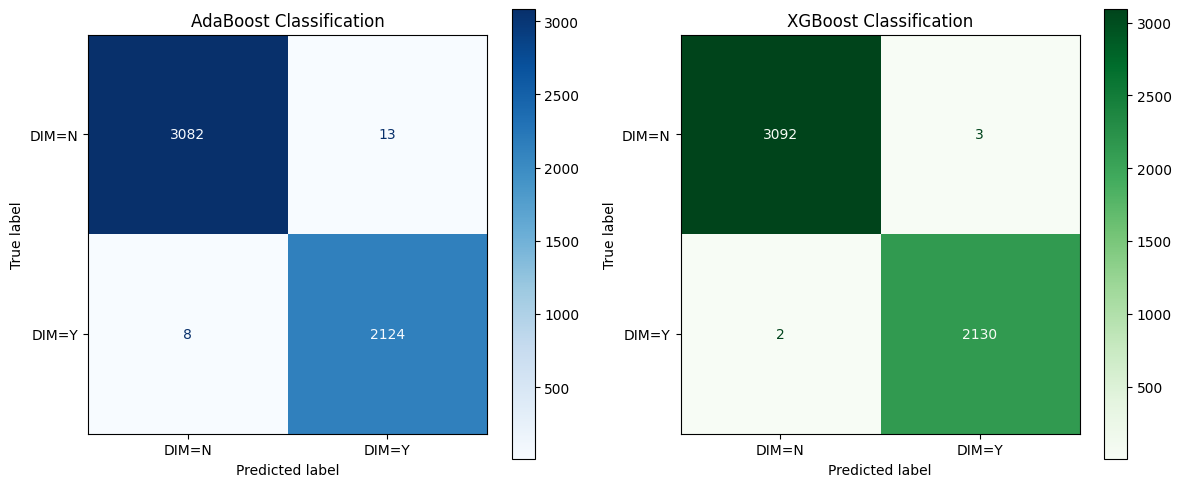

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#AdaBoost confusion matrix
cm_ada = confusion_matrix(y_val_cls, y_val_pred_ada)
ConfusionMatrixDisplay(cm_ada, display_labels=['DIM=N', 'DIM=Y']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('AdaBoost Classification')

#XGBoost confusion matrix
cm_xgb = confusion_matrix(y_val_cls, y_val_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['DIM=N', 'DIM=Y']).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('XGBoost Classification')

plt.tight_layout()
plt.savefig(ROOT / 'figures/boosting_cls_confusion.png', dpi=150)
plt.show()

***7- Regression Scatter Plots***

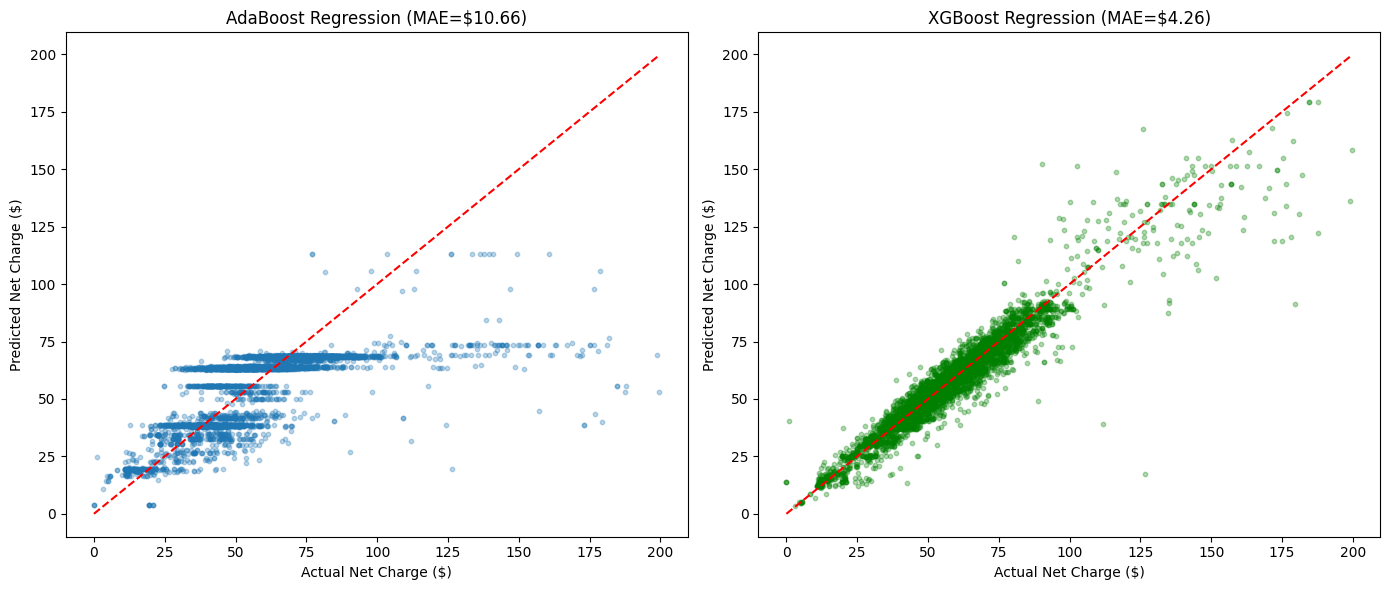

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# AdaBoost scatter
axes[0].scatter(y_val_actual_dollars, y_val_pred_dollars_ada, alpha=0.3, s=10)
axes[0].plot([0, y_val_actual_dollars.max()], [0, y_val_actual_dollars.max()], 'r--')
axes[0].set_xlabel('Actual Net Charge ($)')
axes[0].set_ylabel('Predicted Net Charge ($)')
axes[0].set_title(f'AdaBoost Regression (MAE=${mae_ada:.2f})')

# XGBoost scatter
axes[1].scatter(y_val_actual_dollars, y_val_pred_dollars_xgb, alpha=0.3, s=10, color='green')
axes[1].plot([0, y_val_actual_dollars.max()], [0, y_val_actual_dollars.max()], 'r--')
axes[1].set_xlabel('Actual Net Charge ($)')
axes[1].set_ylabel('Predicted Net Charge ($)')
axes[1].set_title(f'XGBoost Regression (MAE=${mae_xgb:.2f})')

plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'boosting_reg_scatter.png', dpi=150)
plt.show()

***8- SHAP Feature Importance (XGBoost Classification)***

SHAP (SHapley Additive exPlanations) answers the question: "for each individual
  prediction, how much did each feature push the result toward DIM=Y or toward DIM=N?"

**Why SHAP instead of basic feature importance?**
XGBoost has a built-in `.feature_importances_` attribute, but it only tells you HOW OFTEN
a feature was used in tree splits — not WHETHER it pushed predictions up or down.
A feature could be used in 100 splits but have a tiny effect each time.

SHAP gives a signed value for every feature for every row:
- **Positive SHAP value** = this feature pushed the prediction TOWARD DIM=Y for this row
- **Negative SHAP value** = this feature pushed the prediction TOWARD DIM=N for this row
- **Large absolute value** = strong influence
- **Value near zero** = this feature didn't matter much for this prediction

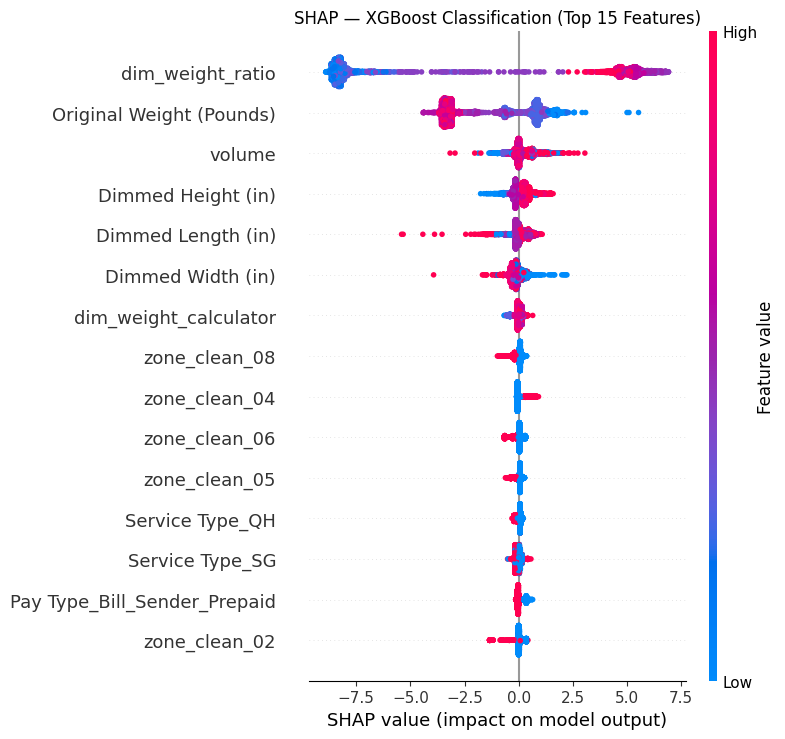

In [18]:
#TreeExplainer is designed for tree models, computes exact SHAP values efficiently
explainer_clf = shap.TreeExplainer(xgb_clf)
shap_values_clf = explainer_clf.shap_values(X_val)

plt.figure()
shap.summary_plot(shap_values_clf, X_val, max_display=15, show=False)
plt.title('SHAP — XGBoost Classification (Top 15 Features)')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'shap_cls_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

***9- SHAP Feature Importance (XGBoost Regression)***

Same SHAP analysis but for the regression model (predicting net charge).

The interpretation changes slightly:
- **Positive SHAP value** = this feature pushed the predicted cost HIGHER
- **Negative SHAP value** = this feature pushed the predicted cost LOWER

This tells us which features drive shipping costs up or down. For example, we'd expect
`Original Weight (Pounds)` to show red dots (heavy packages) on the right side (higher cost)
because heavier packages cost more to ship.

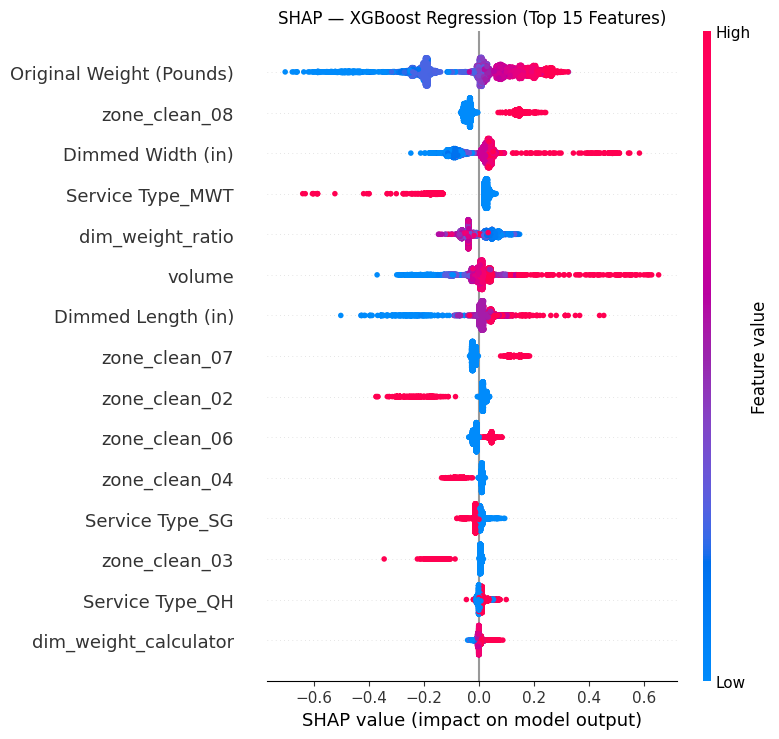

In [19]:
explainer_reg = shap.TreeExplainer(xgb_reg)
shap_values_reg = explainer_reg.shap_values(X_val)

plt.figure()
shap.summary_plot(shap_values_reg, X_val, max_display=15, show=False)
plt.title('SHAP — XGBoost Regression (Top 15 Features)')
plt.tight_layout()
plt.savefig(ROOT / 'figures' / 'shap_reg_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

***10- Summary Table***

All boosting results in one place, compared to the baseline from the previous notebook.

**Baseline numbers (from 03_baseline_models):**
- Task 1 (Logistic Regression): Accuracy 0.9886, Recall 0.9986, F1 0.9861, AUC 0.9901
- Task 2 (Linear Regression): MAE $8.34, RMSE $23.70, R² 0.6982

Classification was already strong at baseline — hard to improve much.
The real test is regression: can boosting models fix the weak R² and outlier problem?

In [20]:
print("=" * 60)
print("BOOSTING RESULTS (Validation Set)")
print("=" * 60)

print("\n--- Task 1: Classification (DIM Flag) ---")
print(f"{'Metric':<12} {'AdaBoost':>10} {'XGBoost':>10}")
print("-" * 34)
print(f"{'Accuracy':<12} {accuracy_score(y_val_cls, y_val_pred_ada):>10.4f} {accuracy_score(y_val_cls, y_val_pred_xgb):>10.4f}")
print(f"{'Precision':<12} {precision_score(y_val_cls, y_val_pred_ada):>10.4f} {precision_score(y_val_cls, y_val_pred_xgb):>10.4f}")
print(f"{'Recall':<12} {recall_score(y_val_cls, y_val_pred_ada):>10.4f} {recall_score(y_val_cls, y_val_pred_xgb):>10.4f}")
print(f"{'F1':<12} {f1_score(y_val_cls, y_val_pred_ada):>10.4f} {f1_score(y_val_cls, y_val_pred_xgb):>10.4f}")
print(f"{'ROC AUC':<12} {roc_auc_score(y_val_cls, y_val_proba_ada):>10.4f} {roc_auc_score(y_val_cls, y_val_proba_xgb):>10.4f}")

print("\n--- Task 2: Regression (Net Charge $) ---")
print(f"{'Metric':<12} {'AdaBoost':>12} {'XGBoost':>12}")
print("-" * 38)
print(f"{'MAE':<12} {'${:.2f}'.format(mae_ada):>12} {'${:.2f}'.format(mae_xgb):>12}")
print(f"{'RMSE':<12} {'${:.2f}'.format(rmse_ada):>12} {'${:.2f}'.format(rmse_xgb):>12}")
print(f"{'R²':<12} {r2_ada:>12.4f} {r2_xgb:>12.4f}")

print("\n--- Baseline Comparison ---")
print("Task 1 Logistic Reg: Acc 0.9931 | Recall 0.9986 | F1 0.9916 | AUC 0.9940")                                              
print("Task 2 Linear Reg:   MAE $7.28  | RMSE $13.05   | R² 0.6897")

BOOSTING RESULTS (Validation Set)

--- Task 1: Classification (DIM Flag) ---
Metric         AdaBoost    XGBoost
----------------------------------
Accuracy         0.9960     0.9990
Precision        0.9939     0.9986
Recall           0.9962     0.9991
F1               0.9951     0.9988
ROC AUC          0.9992     0.9999

--- Task 2: Regression (Net Charge $) ---
Metric           AdaBoost      XGBoost
--------------------------------------
MAE                $10.66        $4.26
RMSE               $16.70        $6.73
R²                 0.4924       0.9174

--- Baseline Comparison ---
Task 1 Logistic Reg: Acc 0.9931 | Recall 0.9986 | F1 0.9916 | AUC 0.9940
Task 2 Linear Reg:   MAE $7.28  | RMSE $13.05   | R² 0.6897
